# TPC-H Q14 Join-Update-Join: Codex 1% (Uniform)

Compares: **SNAP, MONO-NR/RR/WR, DUAL, EPOCH-NR/RR/WR** at 1% update, uniform distribution.

Graph style matches `new_plot.ipynb` (Paul Tol Bright palette, solid=write, hatch=read).

In [23]:
import sys, subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pandas', 'matplotlib'])
print('done')

done



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [24]:
from pathlib import Path
import subprocess, os, sys
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

ROOT = Path('../../').resolve()
SIGMOD = (ROOT / 'benches' / 'sigmod').resolve()
DATA_DIR = SIGMOD / 'tpch_data'
GEN_UPDATES = SIGMOD / 'generate_updates.py'
BIN = ROOT / 'target' / 'release' / 'tpch_q14_join_update_join'

# ===== CONFIG =====
PART_SF      = 1.0
LINEITEM_SF  = 1.0
UPDATE_PCT   = 1.0       # fixed 1%
DIST         = 'zipf0.99'  # 'uniform' or 'zipf0.99'
BUCKET_NUM   = 2048
WARMUP       = 1
REPEAT       = 10
TRIM         = 2

# All series: (table_type, repair_mode)
# DUAL is benchmarked once with WR-mode.
SERIES = [
    ('naive', 'nr'),
    ('heap',  'nr'),
    ('heap',  'rr'),
    ('heap',  'wr'),
    ('chain', 'wr'),
    ('par',   'nr'),
    ('par',   'rr'),
    ('par',   'wr'),
]
# ==================

OUT_CSV = DATA_DIR / 'q14_juj_1pct_snap_mono_dual_epoch_codex.csv'

part_file = DATA_DIR / f'part_sf{PART_SF}.tbl'
probe_file = DATA_DIR / f'lineitem_probe_sf{LINEITEM_SF}_1995-09-01_1995-10-01.tbl'

print('ROOT:', ROOT)
print('CSV :', OUT_CSV)

ROOT: .
CSV : ./benches/sigmod/tpch_data/q14_juj_1pct_snap_mono_dual_epoch_codex.csv


In [25]:
# ── Build Rust binary ──
print('Building tpch_q14_join_update_join...')
result = subprocess.run(
    ['cargo', 'build', '--release', '--bin', 'tpch_q14_join_update_join'],
    cwd=ROOT, capture_output=True, text=True,
)
if result.returncode != 0:
    print('STDERR:', result.stderr)
    raise RuntimeError('cargo build failed')
print('Build OK')

Building tpch_q14_join_update_join...
Build OK


In [26]:
# ── Ensure update file exists ──
pct_label = f'{UPDATE_PCT:g}'
updates_file = DATA_DIR / f'part_updates_sf{PART_SF}_{pct_label}pct_{DIST}.tbl'

if not updates_file.exists():
    print(f'Generating updates: {updates_file.name}')
    subprocess.run([
        sys.executable, str(GEN_UPDATES),
        str(part_file), str(UPDATE_PCT), str(PART_SF),
        '--output-dir', str(DATA_DIR),
    ], check=True, capture_output=True)
else:
    print(f'Updates file exists: {updates_file.name}')

part_rows = sum(1 for _ in open(part_file))
probe_rows = sum(1 for _ in open(probe_file))
update_rows = sum(1 for _ in open(updates_file))
print(f'PART: {part_rows:,}  PROBE: {probe_rows:,}  UPDATES: {update_rows:,}')

Updates file exists: part_updates_sf1.0_1pct_zipf0.99.tbl
PART: 200,000  PROBE: 75,983  UPDATES: 2,000


In [27]:
# ── Run benchmark for all series ──
if OUT_CSV.exists():
    OUT_CSV.unlink()
    print('Removed old CSV')

total_runs = len(SERIES)
for i, (ttype, rmode) in enumerate(SERIES):
    print(f'[{i+1}/{total_runs}] table={ttype} repair={rmode}')
    cmd = [
        str(BIN),
        '--part-file', str(part_file),
        '--lineitem-file', str(probe_file),
        '--updates-file', str(updates_file),
        '--table-type', ttype,
        '--repair-mode', rmode,
        '--bucket-num', str(BUCKET_NUM),
        '--warmup', str(WARMUP),
        '--repeat', str(REPEAT),
        '--trim', str(TRIM),
        '--update-pct', pct_label,
        '--distribution', DIST,
        '--output-csv', str(OUT_CSV),
    ]
    r = subprocess.run(cmd, cwd=ROOT, capture_output=True, text=True)
    if r.returncode != 0:
        print(f'  FAILED: {r.stderr[:400]}')
    else:
        for line in r.stdout.strip().split('\n'):
            if 'total_ms' in line or 'trimmed' in line:
                print(f'  {line.strip()}')

print(f'\nDone. Results -> {OUT_CSV}')

Removed old CSV
[1/8] table=naive repair=nr
  trimmed mean: 10 runs total, dropped 2 lowest + 2 highest, averaging 6 runs
  join1_alloc_ms=0.001139, join1_insert_ms=141.182299, join1_build_ms=141.183438, join1_probe_ms=50.444028, update_ms=0.000021, join2_build_ms=119.285590, join2_probe_ms=51.843632, total_ms=362.756708
[2/8] table=heap repair=nr
  trimmed mean: 10 runs total, dropped 2 lowest + 2 highest, averaging 6 runs
  join1_alloc_ms=58.535417, join1_insert_ms=57.914910, join1_build_ms=116.450326, join1_probe_ms=45.069403, update_ms=0.522375, join2_build_ms=0.000000, join2_probe_ms=43.937139, total_ms=205.979243
[3/8] table=heap repair=rr
  trimmed mean: 10 runs total, dropped 2 lowest + 2 highest, averaging 6 runs
  join1_alloc_ms=64.270792, join1_insert_ms=63.783313, join1_build_ms=128.054105, join1_probe_ms=51.181021, update_ms=0.596889, join2_build_ms=0.000000, join2_probe_ms=62.338882, total_ms=242.170896
[4/8] table=heap repair=wr
  trimmed mean: 10 runs total, dropped 2 l

In [28]:
# ── Load results ──
df = pd.read_csv(OUT_CSV)

# Keep old CSV compatibility: older files may not include split phases.
phase_cols = [
    'join1_alloc_ms', 'join1_insert_ms', 'join1_build_ms', 'join1_probe_ms',
    'update_ms', 'join2_build_ms', 'join2_probe_ms', 'total_join_update_join_ms'
]
has_alloc = 'join1_alloc_ms' in df.columns
has_insert = 'join1_insert_ms' in df.columns
for c in phase_cols:
    if c not in df.columns:
        df[c] = 0.0

if 'join1_build_ms' in df.columns:
    # Legacy format had only join1_build_ms; split as all-insert for compatibility.
    if (not has_alloc) and (not has_insert):
        df['join1_alloc_ms'] = 0.0
        df['join1_insert_ms'] = df['join1_build_ms']
elif (not ('join1_build_ms' in df.columns)):
    df['join1_build_ms'] = (
        pd.to_numeric(df['join1_alloc_ms'], errors='coerce').fillna(0.0)
        + pd.to_numeric(df['join1_insert_ms'], errors='coerce').fillna(0.0)
    )

for c in phase_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0.0)

table_map = {'Heap': 'heap', 'Chain': 'chain', 'Par': 'par', 'Naive': 'naive'}
repair_map = {'Nr': 'NR', 'Rr': 'RR', 'Wr': 'WR'}
df['table'] = df['table_type'].map(table_map).fillna(df['table_type'])
df['repair'] = df['repair_mode'].map(repair_map).fillna(df['repair_mode'])
df.loc[df['table'] == 'naive', 'repair'] = ''

display(df[['table','repair','join1_alloc_ms','join1_insert_ms','join1_build_ms','join1_probe_ms','update_ms','join2_build_ms','join2_probe_ms','total_join_update_join_ms']])

,table,repair,join1_alloc_ms,join1_insert_ms,join1_build_ms,join1_probe_ms,update_ms,join2_build_ms,join2_probe_ms,total_join_update_join_ms
0,naive,,0.001139,141.182299,141.183438,50.444028,0.000021,119.28559,51.843632,362.756708
1,heap,NR,58.535417,57.914910,116.450326,45.069403,0.522375,0.00000,43.937139,205.979243
2,heap,RR,64.270792,63.783313,128.054105,51.181021,0.596889,0.00000,62.338882,242.170896
3,heap,WR,55.614799,54.130090,109.744889,41.291299,1.978167,0.00000,40.020715,193.035069
4,chain,WR,108.703819,50.735931,159.439750,33.787132,2.677500,0.00000,33.930521,229.834903
5,par,NR,46.855097,50.098125,96.953222,36.437694,0.999409,0.00000,50.052861,184.443187
6,par,RR,48.595882,52.544090,101.139972,33.421604,1.410507,0.00000,56.179958,192.152042
7,par,WR,47.985111,51.219785,99.204896,35.977292,3.250271,0.00000,44.148972,182.581430


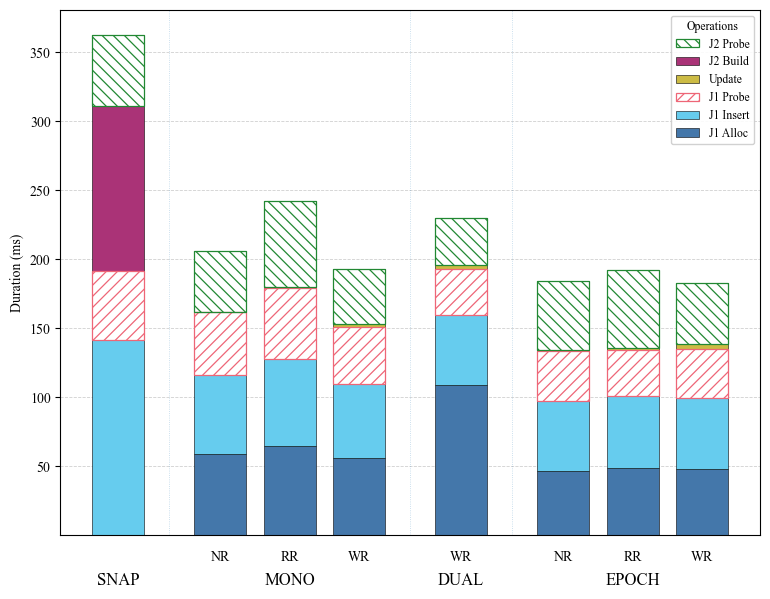

Saved PDF


In [29]:
# ── Grouped stacked bar chart (new_plot.ipynb style) ──

# Paul Tol "Bright" palette
tol = {
    "blue":   "#4477AA",
    "cyan":   "#66CCEE",
    "green":  "#228833",
    "yellow": "#CCBB44",
    "red":    "#EE6677",
    "purple": "#AA3377",
    "grey":   "#BBBBBB",
}

# Phase config: (csv_col, display_name, color, is_write)
phases = [
    ('join1_alloc_ms', 'J1 Alloc',  tol['blue'],   True),
    ('join1_insert_ms', 'J1 Insert', tol['cyan'],  True),
    ('join1_probe_ms', 'J1 Probe',  tol['red'],    False),
    ('update_ms',      'Update',    tol['yellow'], True),
    ('join2_build_ms', 'J2 Build',  tol['purple'], True),
    ('join2_probe_ms', 'J2 Probe',  tol['green'],  False),
]

hatch_map = {
    'J1 Probe': '///',
    'J2 Probe': '\\\\\\',
}

# Table/repair ordering
table_order = ['naive', 'heap', 'chain', 'par']
table_display = {'naive': 'SNAP', 'heap': 'MONO', 'chain': 'DUAL', 'par': 'EPOCH'}
repair_order = {
    'naive': [''],
    'heap':  ['NR', 'RR', 'WR'],
    'chain': ['WR'],
    'par':   ['NR', 'RR', 'WR'],
}

# Font
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif']  = ['Times New Roman', 'Times', 'Nimbus Roman No9 L', 'DejaVu Serif']
plt.rcParams['hatch.linewidth'] = 0.9

# Build combos & x positions
bar_w = 0.58
gap = 0.36
bar_x, minor_labels, major_centers, major_labels, combos = [], [], [], [], []
x = 0.0
for t in table_order:
    subs = repair_order[t]
    start = x
    for r in subs:
        bar_x.append(x)
        minor_labels.append(r)
        combos.append((t, r))
        x += 0.78
    end = x - 0.78
    major_centers.append((start + end) / 2.0)
    major_labels.append(table_display[t])
    x += gap

fig, ax = plt.subplots(figsize=(7.8, 6.0))
fig.subplots_adjust(bottom=0.22)

for i, (t, r) in enumerate(combos):
    row = df[(df['table'] == t) & (df['repair'] == r)]
    if row.empty:
        continue
    row = row.iloc[0]
    bottom = 0.0
    for (col, lbl, color, is_write) in phases:
        v = float(row.get(col, 0.0))
        if v <= 0:
            continue
        if is_write:
            ax.bar(bar_x[i], v, bottom=bottom, width=bar_w,
                   color=color, edgecolor='black', linewidth=0.4, zorder=2)
        else:
            # READ: white base + colored hatch
            ax.bar(bar_x[i], v, bottom=bottom, width=bar_w,
                   color='white', edgecolor='black', linewidth=0.4, zorder=2)
            ax.bar(bar_x[i], v, bottom=bottom, width=bar_w,
                   color='none', edgecolor=color, linewidth=0.9,
                   hatch=hatch_map.get(lbl, '///'), zorder=3)
        bottom += v

# Two-tier x-axis labels
ax.set_xticks([])
for xi, lab in zip(bar_x, minor_labels):
    ax.text(xi, -0.028, lab, ha='center', va='top',
            transform=ax.get_xaxis_transform(), fontsize=10, clip_on=False)
for xc, lab in zip(major_centers, major_labels):
    ax.text(xc, -0.072, lab, ha='center', va='top',
            transform=ax.get_xaxis_transform(), fontsize=12, clip_on=False)

# Separators between major groups
for k in range(1, len(major_centers)):
    prev_end   = max(xx for xx, (tt, _) in zip(bar_x, combos) if tt == table_order[k-1])
    next_start = min(xx for xx, (tt, _) in zip(bar_x, combos) if tt == table_order[k])
    ax.axvline((prev_end + next_start) / 2, linestyle=':', linewidth=0.6, alpha=0.3)

ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
ax.set_ylabel('Duration (ms)')

# Legend (reversed order, matching new_plot style)
handles, labels_leg = [], []
for (col, lbl, color, is_write) in reversed(phases):
    if is_write:
        patch = Patch(facecolor=color, edgecolor='black', linewidth=0.4)
    else:
        patch = Patch(facecolor='white', edgecolor=color,
                      hatch=hatch_map.get(lbl, '///'), linewidth=0.9)
    handles.append(patch)
    labels_leg.append(lbl)

ax.legend(handles, labels_leg, title='Operations',
          loc='upper right', framealpha=0.9, fontsize=8.5, title_fontsize=8.5)

plt.tight_layout()
plt.savefig(str(DATA_DIR / 'q14_juj_1pct_snap_mono_dual_epoch_codex.pdf'), format='pdf')
plt.show()
print('Saved PDF')